In [60]:
import pandas as pd
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np

# 1. Загрузка данных (колонка id становится индексом)
train = pd.read_csv('train.csv', index_col='index')
test = pd.read_csv('test.csv', index_col='index')

# 2. Разделение на признаки и таргет
X_train = train.drop(columns=['target'])
f1 = X_train['f1']
f2 = X_train['f2']
f3 = X_train['f3']
y_train = train['target']
X_test = test

In [61]:
# 3. Обучение простейшей линейной модели
model = PolynomialFeatures(degree=2)
pipeline = make_pipeline(PolynomialFeatures(degree=2),
                                            LinearRegression())
pipeline.fit(X_train, y_train)
print("r2:", pipeline.score(X_train, y_train))

r2: 0.9611159940014793


Бейзлайн обучен. Предсказания сохранены в submission.csv
124.90510077704047
76.0166027007232
178.39952434718697
0.0


/tmp/ipykernel_44897/774611663.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


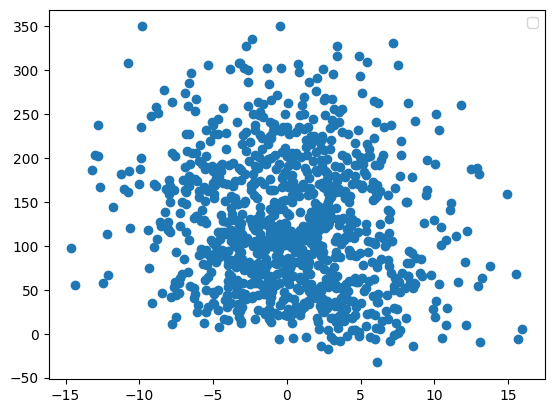

In [63]:
# 4. Предсказание на тестовой выборке
predictions = pipeline.predict(X_test)

# 5. Формирование файла для отправки
submission = pd.DataFrame({
    'index': test.index, 
    'target': predictions
})
submission.to_csv('submission.csv', index=False)

print("Бейзлайн обучен. Предсказания сохранены в submission.csv")
plt.scatter(f2, y_train)
plt.legend()
print(y_train.mean())
print(y_train.std(ddof=1))
print(y_train.quantile(0.75))
print(np.sum(np.square(X_test - X_train)) / (len(X_test) - 1))

